# Complementaria Semana 13: Aplicación de metodologías de verificación y validación para simulaciones

Este notebook introduce los fundamentos de **verificación y validación (V&V)** en modelos de simulación, con énfasis en la diferencia entre comprobar que un programa está correctamente implementado y evaluar si el modelo representa razonablemente el sistema real que se desea estudiar.

Para ello, se construirá y analizará una simulación sencilla de una **cola de un solo servidor**, aplicable a varios servidores. A partir de este ejemplo, se mostrarán procedimientos básicos de verificación computacional, validación estadística y validación conceptual.

El propósito no es solo obtener resultados numéricos, sino entender **cómo confiar, con cautela y evidencia, en un modelo de simulación**.

## Introducción

En simulación, construir un modelo no consiste únicamente en escribir código que corra sin errores. Un modelo puede ejecutarse correctamente y aun así representar mal el sistema real. Del mismo modo, un modelo conceptualmente razonable puede estar mal implementado en el programa.

Por eso, en simulación se distinguen dos procesos fundamentales:

### Verificación
La verificación responde a la pregunta:

$$
\text{¿el modelo computacional fue implementado correctamente?}
$$

En otras palabras, busca comprobar que el código hace lo que se pretendía hacer desde el modelo conceptual.

### Validación
La validación responde a la pregunta:

$$
\text{¿el modelo representa razonablemente el sistema real para el propósito del estudio?}
$$

Aquí el interés no es solo computacional, sino también sustantivo: supuestos, estructura, datos de entrada, salidas y nivel de realismo.


Primero se implementará una simulación de una cola \(M/M/1\), luego se revisará si el código es consistente con el modelo planteado y finalmente se discutirá hasta qué punto ese modelo resulta creíble como representación de un sistema real.

## Objetivos de aprendizaje

Al finalizar este notebook, el estudiante debería poder:

1. Diferenciar entre verificación y validación en simulación.
2. Explicar la relación entre sistema real, modelo conceptual y modelo computacional.
3. Implementar una simulación básica de una cola de un servidor, o varios, en Python.
4. Aplicar pruebas elementales de verificación computacional.
5. Comparar resultados simulados con resultados teóricos del modelo.
6. Discutir la validez conceptual del modelo frente a situaciones reales.

## Fundamentos de verificación y validación en simulación

### Diferencia entre verificación y validación

Aunque suelen mencionarse juntas, verificación y validación no son lo mismo.

### Verificación
La verificación se concentra en el paso de **modelo conceptual** a **modelo computacional**. Su objetivo es revisar si la lógica programada corresponde a la lógica que se deseaba implementar.

Ejemplos de preguntas de verificación:

- ¿Se calculan correctamente los tiempos de espera?
- ¿El servicio inicia solo cuando el cliente ha llegado?
- ¿Se respeta la disciplina de cola (FIFO/FCFS)?
- ¿Se están generando adecuadamente las variables aleatorias?

### Validación
La validación se concentra en el paso de **modelo** a **sistema real**. Su objetivo es evaluar si los supuestos y resultados del modelo son razonables para representar el fenómeno bajo estudio.

Ejemplos de preguntas de validación:

- ¿Es razonable suponer llegadas Poisson?
- ¿Los tiempos de servicio realmente siguen una distribución exponencial?
- ¿Un solo servidor representa adecuadamente el sistema real?
- ¿Las métricas simuladas se parecen a las observadas en la práctica?

En términos simples:

$$
\text{Verificación} \rightarrow \text{“¿lo programé bien?”}
$$

$$
\text{Validación} \rightarrow \text{“¿estoy modelando bien el sistema?”}
$$

## Ejemplo aplicado

### Sistema representado
Puede pensarse en una **cola (M/M/1)** como una ventanilla de atención, una caja, un punto de servicio o una estación de atención con:
- llegadas aleatorias de clientes,
- un solo servidor,
- servicio en orden de llegada,
- y una fila de espera.

### Supuestos del modelo

Los supuestos se declaran explícitamente porque son la base de cualquier proceso de validación.

1. Las llegadas siguen un proceso de Poisson con tasa $\lambda$ (i.e., los tiempos entre llegadas son exponenciales con parámetro $\lambda$).
3. Los tiempos de servicio son exponenciales con parámetro $\mu$.
4. Existe un solo servidor.
5. La cola tiene capacidad infinita.
6. La disciplina de atención es FIFO.
7. No hay abandono, prioridades ni interrupciones.
8. El sistema inicia vacío.

### Variables de interés

A partir de la simulación se calcularán, entre otras, las siguientes métricas:

- tiempo de espera en cola,
- tiempo en el sistema,
- utilización del servidor,
- longitud promedio aproximada de la cola.

Además, este ejemplo permite comparar resultados simulados con fórmulas teóricas del modelo \(M/M/1\), lo cual resulta muy útil para la validación estadística.

## Implementación del modelo en Python

Antes de escribir el código, conviene aclarar la lógica básica de la simulación.

Para cada cliente se generará:
- un tiempo entre llegadas,
- un tiempo de llegada acumulado,
- un tiempo de servicio.

Luego, cliente por cliente, se calculará:
- el inicio de servicio,
- el fin de servicio,
- el tiempo de espera en cola,
- el tiempo total en el sistema.

Como se trata de una cola FIFO con un solo servidor, el inicio de servicio del cliente \(i\) será:

$$
\text{inicio}_i = \max(\text{llegada}_i,\ \text{fin}_{i-1})
$$

y por tanto:

$$
\text{espera}_i = \text{inicio}_i - \text{llegada}_i
$$

$$
\text{fin}_i = \text{inicio}_i + \text{servicio}_i
$$

$$
\text{tiempo en sistema}_i = \text{fin}_i - \text{llegada}_i
$$

A continuación se importan las librerías y se fija una semilla para hacer reproducibles los resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import simpy, random, statistics


Este bloque importa las librerías principales del notebook. `numpy` se usará para generación aleatoria y cálculos numéricos, `pandas` para organizar resultados en tablas, `matplotlib` para visualización y `scipy` para algunas funciones estadísticas. `simpy, random, statistics` se usarán para la modelación de colas



Ahora se reutilizará un modelo introductorio de SimPy aprendido en complementarias anteriores y se definirán dos tipos de trazas, una por cliente y otra por tipo de evento registrado.

Se fija la semilla para revisar si el código produce consistentemente la misma salida bajo las mismas condiciones.

In [2]:
# Guía M/M/1 de la Complementaria introductoria de SimPy

def crear_monitor_mm():
    return {
        "arrivals": 0,        
        "departures": 0,      
        "busy_time": 0.0,     
        "waits": [],          
        "system_times": []    
    }

# Se reordena para incluir la traza en el modelo. Se inicia con la función de simulación y su variable de traza para utilizarla en cada función de la simulación
# Se agregan los parametros de trace y la cantidad máxima a trazar para verificar los primeros clientes, solo sirve si trace=True
def simular_mm(lam=2.0, mu=3.0, T=10_000, s=1, trace=0, max_trace = np.inf, seed = 42):
    
    random.seed(seed)  # fija la aleatoriedad para que el ejemplo sea reproducible
    
    if lam >= mu:
        print("ADVERTENCIA: λ >= μ. En M/M/1 el sistema no es estable; los tiempos pueden crecer sin cota.")
    env = simpy.Environment()
    servidor = simpy.Resource(env, capacity=s) 
    mon = crear_monitor_mm()
    
    #Definimos una función para registrar eventos por cada evento si trace=1
    eventos = []  # Creamos una lista para trazar cada uno de los eventos
    def registro_1(tipo, tiempo, cliente=None):
        if trace == 1 and len(eventos) < max_trace:
            eventos.append({
                "t": round(tiempo, 3),
                "cliente": cliente,
                "evento": tipo,
                "en_servicio": servidor.count,
                "en_cola": len(servidor.queue),
            })
        return eventos

    #Definimos otra función para registrar la información de cada cliente si trace =2
    def registro_2(cliente, interarribo, llegada, servicio, inicio_servicio, fin_servicio, espera_cola, tiempo_sistema):
        if trace == 2 and len(eventos) < max_trace:
            eventos.append({
                "cliente": cliente,
                "interarribo": interarribo,
                "llegada": llegada,
                "servicio": servicio,
                "inicio_servicio": inicio_servicio,
                "fin_servicio": fin_servicio,
                "espera_cola": espera_cola,
                "tiempo_sistema": tiempo_sistema
            })
        return eventos


    def cliente_mm(env, mu, servidor, mon, cid, inter):
        t_llegada = env.now
        #Registro de evento llegada con función registro_1
        registro_1("llega", env.now, cliente=cid)
        with servidor.request() as req:
            yield req  
            #Registro de evento inicio de servicio con función registro_1
            inicio_servicio = env.now
            registro_1("inicio_servicio", env.now, cliente=cid)
            espera_cola = inicio_servicio - t_llegada

            t_serv = random.expovariate(mu)

            mon["busy_time"] += t_serv

            yield env.timeout(t_serv)
            fin_servicio = env.now
                #Registro de evento fin de servicio con función registro_1 o actividad completa de cliente con función registro_2
            registro_1("termina_servicio", env.now, cliente=cid)
            registro_2(cid, inter, t_llegada, t_serv, inicio_servicio, fin_servicio, espera_cola, espera_cola + t_serv)


        mon["waits"].append(espera_cola)
        mon["system_times"].append(espera_cola + t_serv)
        mon["departures"] += 1

    def generador_llegadas_mm(env, lam, mu, servidor, mon):
        #Se agrega un contador de clientes para asignar un ID a cada cliente que llega, esto es útil para el registro de eventos
        i = 0
        while True:
            inter = random.expovariate(lam)
            yield env.timeout(inter)
            i += 1
            mon["arrivals"] += 1
            env.process(cliente_mm(env, mu, servidor, mon, i, inter))



    env.process(generador_llegadas_mm(env, lam, mu, servidor, mon))
    env.run(until=T)

    # Se calculan las métricas de desempeño a partir del monitor
    util_est = mon["busy_time"] / T if T > 0 else 0.0
    Wq_est = statistics.mean(mon["waits"]) if mon["waits"] else 0.0
    W_est  = statistics.mean(mon["system_times"]) if mon["system_times"] else 0.0
    lambda_eff = mon["departures"] / T if T > 0 else 0.0
    L_est  = lambda_eff * W_est
    Lq_est = lambda_eff * Wq_est

    # Teoría M/M/1 (solo si λ < μ)
    if lam < mu:
        rho = lam / mu
        W_theo  = 1.0 / (mu - lam)
        Wq_theo = W_theo - 1.0 / mu
        L_theo  = lam * W_theo
        Lq_theo = lam * Wq_theo
    else:
        rho = float("nan"); W_theo=float("nan"); Wq_theo=float("nan"); L_theo=float("nan"); Lq_theo=float("nan")

    datos = {
        "llegadas": mon["arrivals"],
        "salidas": mon["departures"],
        "utilizacion_est": round(util_est, 4),
        "Wq_est": round(Wq_est, 4),
        "W_est": round(W_est, 4),
        "Lq_est": round(Lq_est, 4),
        "L_est": round(L_est, 4),
        "rho_teorico": round(rho, 4) if rho==rho else rho,
        "W_theo": round(W_theo, 4) if W_theo==W_theo else W_theo,
        "Wq_theo": round(Wq_theo, 4) if Wq_theo==Wq_theo else Wq_theo,
        "L_theo": round(L_theo, 4) if L_theo==L_theo else L_theo,
        "Lq_theo": round(Lq_theo, 4) if Lq_theo==Lq_theo else Lq_theo,
        "trace": [eventos] if trace in [1, 2] else None
    }
    
    return datos





Esto se relaciona con verificación porque deja explícita la implementación del modelo conceptual: primero se generan llegadas y servicios, y luego se calcula la dinámica de atención respetando la lógica FIFO y el hecho de que el servidor solo puede atender a una persona a la vez.

A continuación se ejecutará una corrida base del modelo. Se escogerán parámetros que cumplan la condición de estabilidad:

$$
\rho = \frac{\lambda}{\mu} < 1
$$

> **Nota:** Recordemos que si $\lambda \geq \mu$, el sistema no es estable en el largo plazo y las medidas promedio tienden a crecer sin límite.


In [3]:
lam = 2.0   # tasa de llegadas por unidad de tiempo
mu = 3.0    # tasa de servicio por unidad de tiempo
max_trace = 15

resumen_evento = simular_mm(s = 1)
pd.DataFrame([resumen_evento]).round(4)

,llegadas,salidas,utilizacion_est,Wq_est,W_est,Lq_est,L_est,rho_teorico,W_theo,Wq_theo,L_theo,Lq_theo,trace
0,19973,19972,0.6644,0.6501,0.9827,1.2984,1.9627,0.6667,1.0,0.6667,2.0,1.3333,None


In [4]:
resumen_evento = simular_mm(s = 1, trace=1, max_trace=max_trace)
#Podemos usar la traza y calcular distintas métricas a partir de ella. Estas se pueden comparar con las calculadas directamente en el modelo
pd.DataFrame(resumen_evento["trace"][0]).round(4)


,t,cliente,evento,en_servicio,en_cola
0,0.510,1,llega,0,0
1,0.510,1,inicio_servicio,1,0
2,0.523,2,llega,1,0
3,0.617,1,termina_servicio,1,1
4,0.617,2,inicio_servicio,1,0
5,0.649,3,llega,1,0
6,1.062,2,termina_servicio,1,1
7,1.062,3,inicio_servicio,1,0
8,1.214,4,llega,1,0
9,1.259,5,llega,1,1


La tabla muestra la traza de los primeros eventos en orden consecutivo. Esta traza permite observar coherencia en la evolución del modelo. Note que el primer cliente llega e inicia servicio en el mismo instante, y un cliente que llega cuando hay otro en servicio debe esperar.

In [5]:
resumen_cliente = simular_mm(s = 1, trace=2, max_trace=max_trace)
pd.DataFrame(resumen_cliente["trace"][0]).round(4)

,cliente,interarribo,llegada,servicio,inicio_servicio,fin_servicio,espera_cola,tiempo_sistema
0,1,0.5100,0.5100,0.1072,0.5100,0.6172,0.0000,0.1072
1,2,0.0127,0.5227,0.4445,0.6172,1.0618,0.0945,0.5391
2,3,0.1263,0.6490,0.7424,1.0618,1.8042,0.4128,1.1552
3,4,0.5646,1.2136,0.0090,1.8042,1.8132,0.5906,0.5996
4,5,0.0455,1.2591,0.0739,1.8132,1.8871,0.5541,0.6280
5,6,0.2740,1.5331,0.3498,1.8871,2.2369,0.3540,0.7038
6,7,0.0151,1.5482,0.0830,2.2369,2.3199,0.6887,0.7717
7,8,0.1234,1.6716,0.2966,2.3199,2.6165,0.6483,0.9449
8,9,0.3520,2.0235,0.0022,2.6165,2.6187,0.5930,0.5952
9,10,0.3937,2.4172,0.5463,2.6187,3.1650,0.2015,0.7478


Esta tabla muestra la traza de los primeros clientes. Allí se observa, para cada uno, cuándo llega, cuánto dura su servicio, cuándo empieza a ser atendido, cuándo termina y cuánto espera.

Esta traza es clave para la verificación, porque permite revisar si la simulación sigue la lógica esperada del sistema.

In [57]:
resumen_cliente_s2 = simular_mm(s = 2, trace=2, max_trace=max_trace)
pd.DataFrame(resumen_cliente_s2["trace"][0]).round(4)

,cliente,interarribo,llegada,servicio,inicio_servicio,fin_servicio,espera_cola,tiempo_sistema
0,1,0.5100,0.5100,0.1072,0.5100,0.6172,0.0000,0.1072
1,2,0.0127,0.5227,0.4445,0.5227,0.9672,0.0000,0.4445
2,3,0.1263,0.6490,0.7424,0.6490,1.3914,0.0000,0.7424
3,4,0.5646,1.2136,0.1827,1.2136,1.3963,0.0000,0.1827
4,6,0.0151,1.2742,0.0090,1.3963,1.4052,0.1221,0.1310
5,5,0.0455,1.2591,0.2346,1.3914,1.6261,0.1324,0.3670
6,8,0.1108,1.5084,0.0830,1.6261,1.7091,0.1177,0.2007
7,7,0.1234,1.3975,0.3498,1.4052,1.7551,0.0077,0.3575
8,9,0.3937,1.9020,0.5526,1.9020,2.4546,0.0000,0.5526
9,11,0.0033,2.3502,0.1386,2.4546,2.5933,0.1044,0.2430


Si se modifican parámetros como el número de servidores se pueden observar cambios como en tiempos de espera y se verifica que el modelo sirva en general, no solo para los parámetros indicados inicialmente.

Antes de calcular indicadores agregados, conviene resumir algunas métricas básicas de la corrida a partir de las trazas. Esto servirá más adelante para comparar con resultados teóricos y para discutir validación estadística.

In [6]:
resumen_cliente = simular_mm(s = 1, trace=2)
df = pd.DataFrame(resumen_cliente["trace"][0])

resumen_base = {
    "clientes_simulados": len(df),
    "espera_promedio_cola": df["espera_cola"].mean(),
    "tiempo_promedio_sistema": df["tiempo_sistema"].mean(),
    "tiempo_promedio_servicio": df["servicio"].mean(),
    "tiempo_total_simulado": df["fin_servicio"].iloc[-1],
    "tiempo_ocupado": df["servicio"].sum(),
    "utilizacion_aprox": df["servicio"].sum() / df["fin_servicio"].iloc[-1]
}


pd.Series(resumen_base)


clientes_simulados          19972.000000
espera_promedio_cola            0.650104
tiempo_promedio_sistema         0.982742
tiempo_promedio_servicio        0.332637
tiempo_total_simulado        9999.232488
tiempo_ocupado               6643.431351
utilizacion_aprox               0.664394
dtype: float64

Este resumen agrega medidas de desempeño de la corrida. En particular, la utilización aproximada del servidor se calcula como la fracción del tiempo total en la que el servidor estuvo ocupado.

Estas métricas todavía no validan el modelo, pero sí preparan el terreno para comparar lo simulado con lo esperado teóricamente y revisar si los resultados son razonables.
Además, se pueden comparar directamente con los resultados obtenidos en la función simular_mm. 

In [59]:
resumen_cliente

{'llegadas': 19973,
 'salidas': 19972,
 'utilizacion_est': 0.6644,
 'Wq_est': 0.6501,
 'W_est': 0.9827,
 'Lq_est': 1.2984,
 'L_est': 1.9627,
 'rho_teorico': 0.6667,
 'W_theo': 1.0,
 'Wq_theo': 0.6667,
 'L_theo': 2.0,
 'Lq_theo': 1.3333,
 'trace': [[{'cliente': 1,
    'interarribo': 0.5100301436374005,
    'llegada': 0.5100301436374005,
    'servicio': 0.10720802135832186,
    'inicio_servicio': 0.5100301436374005,
    'fin_servicio': 0.6172381649957224,
    'espera_cola': 0.0,
    'tiempo_sistema': 0.10720802135832186},
   {'cliente': 2,
    'interarribo': 0.012664419521369446,
    'llegada': 0.5226945631587699,
    'servicio': 0.44453089093602766,
    'inicio_servicio': 0.6172381649957224,
    'fin_servicio': 1.06176905593175,
    'espera_cola': 0.09454360183695243,
    'tiempo_sistema': 0.53907449277298},
   {'cliente': 3,
    'interarribo': 0.12629309283505677,
    'llegada': 0.6489876559938267,
    'servicio': 0.7424293665171269,
    'inicio_servicio': 1.06176905593175,
    'fin_se

La comparación de resultados es la siguiente:

| Métrica               | Medición monitor                 | Medición traza                           |
|-----------------------|----------------------------------|------------------------------------------|
| Clientes              | 'salidas'=19972                  | clientes_simulados = 19972               |
| Espera promedio cola  | 'Wq_est' ≈ 0.6501                | espera_promedio_cola ≈ 0.6501            |
| Espera promedio total | 'W_est' ≈ 0.9827                 | espera_promedio_sistema ≈ 0.9827         |
| Tiempo total          | T = 10000                        | tiempo_total_simulado ≈ 9999.23          |
| Utilización           | 'utilizacion_est' ≈ 0.6644       | utilizacion_aprox ≈ 0.6644               |

Estos resultados aumentan la confiabilidad del modelo.

## Verificación computacional del modelo

La verificación busca comprobar que el código implementa correctamente el modelo conceptual. En este notebook se revisarán cuatro tipos de chequeos:

1. Revisión de dimensiones,
2. Revisión de valores imposibles,
3. Pruebas de consistencia lógica,
4. Revisión visual de salidas.

La idea no es “probar matemáticamente” que el código es perfecto, sino buscar evidencia de que se comporta como debería.

### Revisión de dimensiones y estructura

Primero conviene revisar si la tabla de salida tiene el número correcto de filas y si las columnas esperadas están presentes. Muchas veces los errores de implementación comienzan por estructuras mal armadas.

In [60]:
columnas_esperadas = [
    "cliente", "interarribo", "llegada", "servicio",
    "inicio_servicio", "fin_servicio", "espera_cola", "tiempo_sistema"
]

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Columnas correctas:", list(df.columns) == columnas_esperadas)
print("Número de clientes esperado:", resumen_cliente["salidas"])

Número de filas: 19972
Número de columnas: 8
Columnas correctas: True
Número de clientes esperado: 19972


In [61]:
pd.DataFrame(resumen_cliente["trace"][0]).round(4)

,cliente,interarribo,llegada,servicio,inicio_servicio,fin_servicio,espera_cola,tiempo_sistema
0,1,0.5100,0.5100,0.1072,0.5100,0.6172,0.0000,0.1072
1,2,0.0127,0.5227,0.4445,0.6172,1.0618,0.0945,0.5391
2,3,0.1263,0.6490,0.7424,1.0618,1.8042,0.4128,1.1552
3,4,0.5646,1.2136,0.0090,1.8042,1.8132,0.5906,0.5996
4,5,0.0455,1.2591,0.0739,1.8132,1.8871,0.5541,0.6280
...,...,...,...,...,...,...,...,...
19967,19968,1.7914,9996.8909,0.3341,9996.8909,9997.2250,0.0000,0.3341
19968,19969,0.2425,9997.1334,0.2683,9997.2250,9997.4933,0.0916,0.3599
19969,19970,0.5530,9997.6865,0.2850,9997.6865,9997.9714,0.0000,0.2850
19970,19971,0.0032,9997.6896,0.5881,9997.9714,9998.5595,0.2818,0.8699


Este chequeo confirma si la salida tiene la forma esperada. En verificación, revisar dimensiones y nombres de variables ayuda a detectar errores tempranos de estructura, por ejemplo columnas faltantes o resultados truncados.

### Revisión de valores imposibles

Ahora se comprobará que no existan valores que contradigan la lógica del modelo, como tiempos negativos o tiempos de fin menores que tiempos de inicio.

In [ ]:
print("¿Hay interarribos negativos?:", (df["interarribo"] < 0).any())
print("¿Hay servicios negativos?:", (df["servicio"] < 0).any())
print("¿Hay esperas negativas?:", (df["espera_cola"] < 0).any())
print("¿Hay tiempos de sistema negativos?:", (df["tiempo_sistema"] < 0).any())
print("¿Hay fin de servicio menor que inicio?:", (df["fin_servicio"] < df["inicio_servicio"]).any())
print("¿Hay inicio de servicio antes de la llegada?:", (df["inicio_servicio"] < df["llegada"]).any())
print("¿El primer cliente llega después del tiempo 0?:", df["llegada"].iloc[0] >= 0)

¿Hay interarribos negativos?: False
¿Hay servicios negativos?: False
¿Hay esperas negativas?: False
¿Hay tiempos de sistema negativos?: False
¿Hay fin de servicio menor que inicio?: False
¿Hay inicio de servicio antes de la llegada?: False
¿El primer cliente llega después de tiempo 0?: True


Si alguna de estas condiciones resultara verdadera, a excepción de la última, habría un problema serio de implementación o de lógica.

Desde la verificación, este tipo de revisión es esencial porque descarta resultados físicamente o lógicamente imposibles.

### Pruebas de consistencia lógica

Además de evitar valores imposibles, el modelo debe respetar relaciones internas entre variables. Por ejemplo:

$$
\text{espera en cola} = \text{inicio de servicio} - \text{llegada}
$$

$$
\text{tiempo en sistema} = \text{fin de servicio} - \text{llegada}
$$

$$
\text{fin de servicio} = \text{inicio de servicio} + \text{servicio}
$$

También debe cumplirse que el servidor no atienda a dos clientes al mismo tiempo, lo cual implica que el inicio del servicio del cliente \(i\) no puede ser menor que el fin del cliente \(i-1\).

In [7]:
tol = 1e-10

consistencia_espera = np.allclose(
    df["espera_cola"],
    df["inicio_servicio"] - df["llegada"],
    atol=tol  #atol compara la diferencia absoluta, rtol compara la diferencia relativa y equal_nan = True considera NaNs como iguales a cualquier otro valor
)

consistencia_sistema = np.allclose(
    df["tiempo_sistema"],
    df["fin_servicio"] - df["llegada"],
    atol=tol
)

consistencia_fin = np.allclose(
    df["fin_servicio"],
    df["inicio_servicio"] + df["servicio"],
    atol=tol
)

no_solapamiento = True
for i in range(1, len(df)):
    if df.loc[i, "inicio_servicio"] < min(df.loc[i, "llegada"], df.loc[i-1, "fin_servicio"]):
        no_solapamiento = False
        break

llegadas_ordenadas = (df["llegada"].diff().fillna(0) >= -tol).all()
fines_ordenados = (df["fin_servicio"].diff().fillna(0) >= -tol).all()

print("Consistencia de espera:", consistencia_espera)
print("Consistencia de tiempo en sistema:", consistencia_sistema)
print("Consistencia de fin de servicio:", consistencia_fin)
print("Llegadas no decrecientes:", llegadas_ordenadas)
print("Fines de servicio no decrecientes:", fines_ordenados)
print("No hay violación evidente de la lógica de servicio:", no_solapamiento)

Consistencia de espera: True
Consistencia de tiempo en sistema: True
Consistencia de fin de servicio: True
Llegadas no decrecientes: True
Fines de servicio no decrecientes: True
No hay violación evidente de la lógica de servicio: True


Estas pruebas verifican relaciones internas del modelo. Si estas identidades no se cumplen, el programa no está implementando correctamente la lógica definida.

Aquí la verificación ya no es solo “que el código corra”, sino que produzca resultados coherentes con el modelo conceptual.

### Caso deterministico y trazable para depuración

Una estrategia clásica de verificación consiste en usar un caso deterministico, donde sea posible seguir cada paso del cálculo con certeza. Para esto, modificaremos la simulación inicial con tiempos determinísticos prefijados.

La idea es muy simple: si con tiempos conocidos el código produce exactamente lo esperado, aumenta la confianza en la implementación.

In [8]:

def crear_monitor_dd():
    return {
        "arrivals": 0,        
        "departures": 0,      
        "busy_time": 0.0,     
        "waits": [],          
        "system_times": []    
    }


def simular_dd(lam=2.0, mu=3.0, T=10_000, s=1, trace=0, max_trace = np.inf, seed = 42):
    
    # No es necesaria la semilla por ser deterministico
    
    if lam >= mu:
        print("ADVERTENCIA: λ >= μ. En M/M/1 el sistema no es estable; los tiempos pueden crecer.")
    env = simpy.Environment()
    servidor = simpy.Resource(env, capacity=s) 
    mon = crear_monitor_dd()
    
    eventos = []  
    def registro_1(tipo, tiempo, cliente=None):
        if trace == 1 and len(eventos) < max_trace:
            eventos.append({
                "t": round(tiempo, 3),
                "cliente": cliente,
                "evento": tipo,
                "en_servicio": servidor.count,
                "en_cola": len(servidor.queue),
            })
        return eventos

    def registro_2(cliente, interarribo, llegada, servicio, inicio_servicio, fin_servicio, espera_cola, tiempo_sistema):
        if trace == 2 and len(eventos) < max_trace:
            eventos.append({
                "cliente": cliente,
                "interarribo": interarribo,
                "llegada": llegada,
                "servicio": servicio,
                "inicio_servicio": inicio_servicio,
                "fin_servicio": fin_servicio,
                "espera_cola": espera_cola,
                "tiempo_sistema": tiempo_sistema
            })
        return eventos


    def cliente_dd(env, mu, servidor, mon, cid, inter):
        t_llegada = env.now
        
        registro_1("llega", env.now, cliente=cid)
        with servidor.request() as req:
            yield req  
            
            inicio_servicio = env.now
            registro_1("inicio_servicio", env.now, cliente=cid)
            espera_cola = inicio_servicio - t_llegada
            #----------------------------------------------------------------------------------------------------------------------------------------
            t_serv = 1/mu # se utiliza un valor fijo para verificar la traza, se puede cambiar por random.expovariate(mu) para que sea aleatorio
            #----------------------------------------------------------------------------------------------------------------------------------------
            mon["busy_time"] += t_serv

            yield env.timeout(t_serv)
            fin_servicio = env.now
                
            registro_1("termina_servicio", env.now, cliente=cid)
            registro_2(cid, inter, t_llegada, t_serv, inicio_servicio, fin_servicio, espera_cola, espera_cola + t_serv)


        mon["waits"].append(espera_cola)
        mon["system_times"].append(espera_cola + t_serv)
        mon["departures"] += 1

    def generador_llegadas_dd(env, lam, mu, servidor, mon):
        
        i = 0
        while True:
            #----------------------------------------------------------------------------------------------------------------------------------------
            inter = 1/lam # se utiliza un valor fijo para verificar la traza, se puede cambiar por random.expovariate(lam) para que sea aleatorio
            #----------------------------------------------------------------------------------------------------------------------------------------
            yield env.timeout(inter)
            i += 1
            mon["arrivals"] += 1
            env.process(cliente_dd(env, mu, servidor, mon, i, inter))



    env.process(generador_llegadas_dd(env, lam, mu, servidor, mon))
    env.run(until=T)


    util_est = mon["busy_time"] / T if T > 0 else 0.0
    Wq_est = statistics.mean(mon["waits"]) if mon["waits"] else 0.0
    W_est  = statistics.mean(mon["system_times"]) if mon["system_times"] else 0.0
    lambda_eff = mon["departures"] / T if T > 0 else 0.0
    L_est  = lambda_eff * W_est
    Lq_est = lambda_eff * Wq_est

    # Teoría M/M/1 (solo si λ < μ)
    if lam < mu:
        rho = lam / mu
        W_theo  = 1.0 / (mu - lam)
        Wq_theo = W_theo - 1.0 / mu
        L_theo  = lam * W_theo
        Lq_theo = lam * Wq_theo
    else:
        rho = float("nan"); W_theo=float("nan"); Wq_theo=float("nan"); L_theo=float("nan"); Lq_theo=float("nan")

    datos = {
        "llegadas": mon["arrivals"],
        "salidas": mon["departures"],
        "utilizacion_est": round(util_est, 4),
        "Wq_est": round(Wq_est, 4),
        "W_est": round(W_est, 4),
        "Lq_est": round(Lq_est, 4),
        "L_est": round(L_est, 4),
        "rho_teorico": round(rho, 4) if rho==rho else rho,
        "W_theo": round(W_theo, 4) if W_theo==W_theo else W_theo,
        "Wq_theo": round(Wq_theo, 4) if Wq_theo==Wq_theo else Wq_theo,
        "L_theo": round(L_theo, 4) if L_theo==L_theo else L_theo,
        "Lq_theo": round(Lq_theo, 4) if Lq_theo==Lq_theo else Lq_theo,
        "trace": [eventos] if trace in [1, 2] else None
    }
    
    return datos



dds = simular_dd(trace=2)
df_dd = pd.DataFrame(dds["trace"][0])
df_dd.round(4)

,cliente,interarribo,llegada,servicio,inicio_servicio,fin_servicio,espera_cola,tiempo_sistema
0,1,0.5,0.5,0.3333,0.5,0.8333,0.0,0.3333
1,2,0.5,1.0,0.3333,1.0,1.3333,0.0,0.3333
2,3,0.5,1.5,0.3333,1.5,1.8333,0.0,0.3333
3,4,0.5,2.0,0.3333,2.0,2.3333,0.0,0.3333
4,5,0.5,2.5,0.3333,2.5,2.8333,0.0,0.3333
...,...,...,...,...,...,...,...,...
19994,19995,0.5,9997.5,0.3333,9997.5,9997.8333,0.0,0.3333
19995,19996,0.5,9998.0,0.3333,9998.0,9998.3333,0.0,0.3333
19996,19997,0.5,9998.5,0.3333,9998.5,9998.8333,0.0,0.3333
19997,19998,0.5,9999.0,0.3333,9999.0,9999.3333,0.0,0.3333


Este bloque elimina el componente aleatorio y usa datos controlados. Eso permite verificar el cálculo cliente a cliente.

Esta técnica es muy útil porque reduce la incertidumbre del experimento y hace más fácil encontrar errores de programación.

Ahora se compararán los resultados de esa tabla con cálculos manuales esperados.

Las llegadas deberían ser:
$$
\text{cliente 1: } \frac{1}{\lambda}
$$
$$
\text{cliente 2: } \frac{2}{\lambda}
$$
$$
\text{...}
$$
$$
\text{cliente n: } \frac{n}{\lambda}$$

Y los servicios siempre son:

$$
\text{cliente i: } \frac{1}{\mu}
$$


Luego, los tiempos de inicio, fin y espera se pueden calcular manualmente para confirmar la lógica.

In [9]:
llegadas_esperadas = np.arange(dds["llegadas"]) * (1/lam) + 0.5 # se espera que las llegadas sean cada 0.5 unidades de tiempo, comenzando en 1
#También se puede crear un arreglo con paso fijo con np.range(start, stop, step)
inicio_esperado = llegadas_esperadas
fin_esperado = llegadas_esperadas + 1/mu
espera_esperada = np.zeros(len(llegadas_esperadas))
sistema_esperado = np.array([1/mu] * len(llegadas_esperadas)) # como el servicio es determinístico, el tiempo en sistema es igual al tiempo de servicio
print("Llegadas correctas:", np.allclose(df_dd["llegada"], llegadas_esperadas, atol=tol))
print("Inicios correctos:", np.allclose(df_dd["inicio_servicio"], inicio_esperado, atol=tol))
print("Fines correctos:", np.allclose(df_dd["fin_servicio"], fin_esperado, atol=tol))
print("Esperas correctas:", np.allclose(df_dd["espera_cola"], espera_esperada, atol=tol))
print("Tiempos en sistema correctos:", np.allclose(df_dd["tiempo_sistema"], sistema_esperado, atol=tol))

Llegadas correctas: True
Inicios correctos: True
Fines correctos: True
Esperas correctas: True
Tiempos en sistema correctos: True


Cuando el código reproduce correctamente un ejemplo manual, se fortalece la evidencia de verificación.

No demuestra que el modelo sea válido para la realidad, pero sí apoya que la implementación refleja la lógica deseada.

### Revisión visual de salidas

Además de los chequeos numéricos, conviene observar visualmente algunas salidas. Una gráfica simple puede ayudar a detectar patrones extraños, errores de escala o comportamientos inesperados.

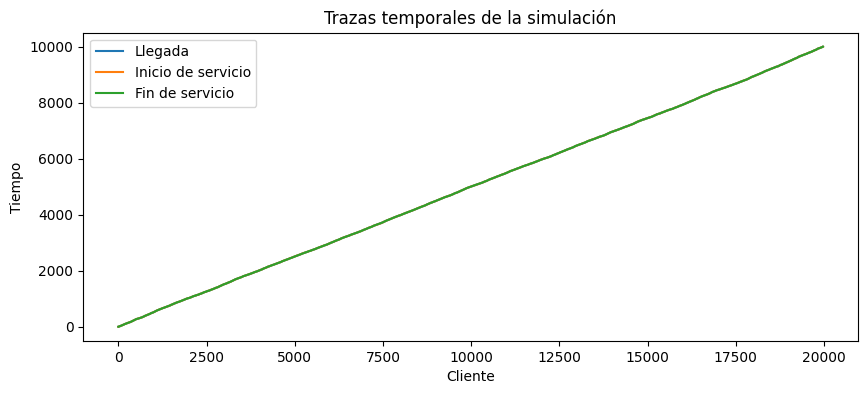

In [66]:
plt.figure(figsize=(10, 4))
plt.plot(df["cliente"], df["llegada"], label="Llegada")
plt.plot(df["cliente"], df["inicio_servicio"], label="Inicio de servicio")
plt.plot(df["cliente"], df["fin_servicio"], label="Fin de servicio")
plt.xlabel("Cliente")
plt.ylabel("Tiempo")
plt.title("Trazas temporales de la simulación")
plt.legend()
plt.show()

La gráfica muestra la evolución temporal del proceso. Se espera que las tres curvas sean no decrecientes y que el inicio de servicio nunca ocurra antes de la llegada.

Esta inspección visual se conoce en la literatura como **Face Validity** (Validez Aparente): una revisión rápida por parte de un experto para confirmar que el comportamiento del modelo "tiene sentido" y no presenta anomalías evidentes.

La inspección visual no reemplaza los chequeos lógicos, pero complementa la verificación al permitir detectar comportamientos que a veces no saltan a la vista en una tabla.

Para evaluar segmentos específicos se puede evaluar un número limitado de clientes.

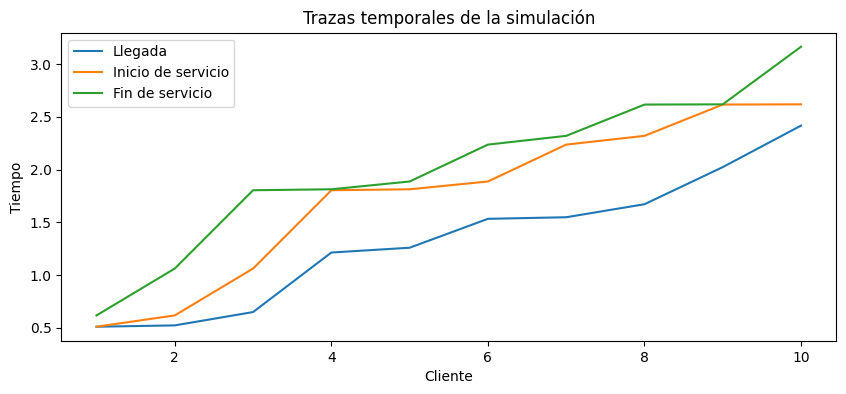

In [67]:
plt.figure(figsize=(10, 4))
plt.plot(df[:10]["cliente"], df[:10]["llegada"], label="Llegada")
plt.plot(df[:10]["cliente"], df[:10]["inicio_servicio"], label="Inicio de servicio")
plt.plot(df[:10]["cliente"], df[:10]["fin_servicio"], label="Fin de servicio")
plt.xlabel("Cliente")
plt.ylabel("Tiempo")
plt.title("Trazas temporales de la simulación")
plt.legend()
plt.show()

Con clientes limitados puede verificarse el funcionamiento del modelo con más precisión.

## Validación estadística y conceptual

Una vez verificado el código, la siguiente pregunta es si el modelo representa razonablemente el sistema de interés.

En este notebook se abordarán dos niveles de validación:

1. **validación estadística**, comparando resultados simulados con resultados teóricos del modelo \(M/M/1\);
2. **validación conceptual**, discutiendo qué tan plausibles son los supuestos frente a un sistema real.

### Validación estadística: comparación con resultados teóricos

Para una cola $M/M/1$ estable, con $\rho = \lambda/\mu < 1$, se tienen las siguientes expresiones teóricas:

$$
\rho = \frac{\lambda}{\mu}
$$

$$
W_q = \frac{\lambda}{\mu(\mu-\lambda)}
$$

$$
W = \frac{1}{\mu-\lambda}
$$

$$
L_q = \lambda W_q
$$

$$
L = \lambda W
$$

donde:
- $W_q$ es el tiempo promedio en cola,
- $W$ es el tiempo promedio en el sistema,
- $L_q$ es el número promedio en cola,
- $L$ es el número promedio en el sistema.

Estas fórmulas constituyen una referencia muy útil para validar estadísticamente la simulación.

In [10]:
rho = lam / mu
Wq_teorico = lam / (mu * (mu - lam))
W_teorico = 1 / (mu - lam)
Lq_teorico = lam * Wq_teorico
L_teorico = lam * W_teorico

pd.Series({
    "rho": rho,
    "Wq_teorico": Wq_teorico,
    "W_teorico": W_teorico,
    "Lq_teorico": Lq_teorico,
    "L_teorico": L_teorico
})

rho           0.666667
Wq_teorico    0.666667
W_teorico     1.000000
Lq_teorico    1.333333
L_teorico     2.000000
dtype: float64

Estos valores representan el comportamiento esperado del modelo ideal \(M/M/1\) en régimen estable.

Comparar la simulación con estas expresiones ayuda a la validación estadística, porque permite revisar si el comportamiento promedio del programa coincide con lo que la teoría predice para ese mismo modelo.

Una sola corrida puede estar afectada por variabilidad aleatoria. Por eso, para validar estadísticamente, es preferible usar varias réplicas independientes y observar la distribución de los resultados.

In [69]:
def ejecutar_replicas(n_replicas, lam = lam, mu = mu, T = 10_000, s = 1, trace = 2):
    resultados = []

    for r in range(n_replicas):
        sim_data = simular_mm(lam = lam, mu = mu, T = T, s = s, trace = trace, seed=42 + r)
        df_r = pd.DataFrame(sim_data["trace"][0])

        tiempo_total = df_r["fin_servicio"].iloc[-1]
        utilizacion = df_r["servicio"].sum() / (s * tiempo_total)

        resultados.append({
            "replica": r + 1,
            "Wq_sim": df_r["espera_cola"].mean(),
            "W_sim": df_r["tiempo_sistema"].mean(),
            "rho_sim": utilizacion
        })

    return pd.DataFrame(resultados)


replicas = ejecutar_replicas(n_replicas=200)
replicas.head(10)

,replica,Wq_sim,W_sim,rho_sim
0,1,0.650104,0.982742,0.664394
1,2,0.655886,0.990876,0.660817
2,3,0.673513,1.009994,0.665373
3,4,0.686564,1.020771,0.672797
4,5,0.671734,1.004162,0.667602
5,6,0.620374,0.956031,0.662000
6,7,0.608650,0.941430,0.652286
7,8,0.635990,0.965476,0.661058
8,9,0.656606,0.989218,0.659163
9,10,0.695628,1.031076,0.671371


Este bloque ejecuta varias réplicas independientes del modelo y resume, para cada una, el tiempo promedio en cola, el tiempo promedio en sistema y una aproximación de la utilización del servidor.

Trabajar con múltiples réplicas es importante en validación estadística porque permite distinguir entre discrepancias debidas al azar y discrepancias sistemáticas del modelo.

Ahora se resumirán las salidas de las réplicas y se compararán con los valores teóricos.

In [70]:
resumen_replicas = pd.Series({
    "Wq_sim": replicas["Wq_sim"].mean(),
    "Wq_teorico": Wq_teorico,
    "W_sim": replicas["W_sim"].mean(),
    "W_teorico": W_teorico,
    "rho_sim": replicas["rho_sim"].mean(),
    "rho_teorico": rho
})

resumen_replicas

Wq_sim         0.665664
Wq_teorico     0.666667
W_sim          0.999084
W_teorico      1.000000
rho_sim        0.666230
rho_teorico    0.666667
dtype: float64

Si la simulación está bien implementada y el número de clientes por réplica es suficiente, las medias simuladas deberían acercarse a los valores teóricos.

Esto no prueba validez frente al sistema real, pero sí respalda que el modelo computacional reproduce adecuadamente el comportamiento esperado del modelo matemático \(M/M/1\).

También puede ser útil construir intervalos de confianza aproximados para las medias simuladas. Así se observa si los valores teóricos quedan dentro del rango de variabilidad de las réplicas.

In [71]:
def intervalo_confianza_95(x):
    media = np.mean(x)
    s = np.std(x, ddof=1)
    n = len(x)
    margen = stats.t.ppf(0.975, df=n-1) * s / np.sqrt(n) #Recuerden que para muestras aleatorias se utiliza la distribución t de Student, no la normal
                                                        # la aproximación de la normal se puede usar para muestras grandes (n > 30) pero es recomendable usar t para ser más precisos
                                                        # t se aproxima cada vez más a la normal a medida que n crece, por eso es una buena opción para cualquier tamaño de muestra
    return media, media - margen, media + margen  # Para variables con dominio positivo, se puede hacer un condicional para que el límite inferior no sea negativo, por ejemplo: max(0, media - margen)
                                                  # Si se piensa calcular ic para variables con y sin esta característica, se puede agregar un parámetro a la función para controlar esto

ic_Wq = intervalo_confianza_95(replicas["Wq_sim"])
ic_W = intervalo_confianza_95(replicas["W_sim"])
ic_rho = intervalo_confianza_95(replicas["rho_sim"])


# Podemos resumir los resultados de las réplicas con sus intervalos de confianza y compararlos con los valores teóricos
def resumen_ic(df, metricas):
    out = []
    for m in metricas:
        media, li, ls = intervalo_confianza_95(df[m])
        out.append({
            "metrica": m,
            "media": media,
            "IC95_inf": li,
            "IC95_sup": ls,
            "valor_teorico": resumen_replicas[m.replace("_sim", "_teorico")]
        })
    return pd.DataFrame(out)

# Metricas a comparar entre simulación y teoría
metricas = ["Wq_sim", "W_sim", "rho_sim"]

resumen_ic(replicas, metricas).round(4)

,metrica,media,IC95_inf,IC95_sup,valor_teorico
0,Wq_sim,0.6657,0.6606,0.6707,0.6667
1,W_sim,0.9991,0.9938,1.0043,1.0000
2,rho_sim,0.6662,0.6652,0.6672,0.6667


Los intervalos de confianza permiten una lectura más cuidadosa que una simple comparación puntual.

Si los valores teóricos se encuentran razonablemente cerca de los resultados simulados, ello aporta evidencia a favor de la validez estadística del programa respecto al modelo teórico.

### Revisión visual de la validación estadística

Además de los resúmenes numéricos, una comparación visual ayuda a interpretar la cercanía entre simulación y teoría.

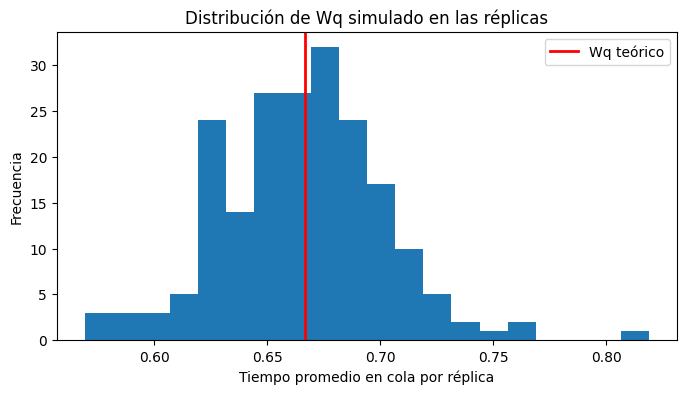

In [72]:
plt.figure(figsize=(8, 4))
plt.hist(replicas["Wq_sim"], bins=20)
plt.axvline(Wq_teorico, linewidth=2, label="Wq teórico", color="red")
plt.xlabel("Tiempo promedio en cola por réplica")
plt.ylabel("Frecuencia")
plt.title("Distribución de Wq simulado en las réplicas")
plt.legend()
plt.show()

El histograma muestra cómo varía el tiempo promedio en cola entre réplicas y ubica el valor teórico como referencia.

Esta revisión visual contribuye a la validación estadística porque permite ver si la teoría aparece como un valor compatible con la variabilidad natural de la simulación.

### Validación conceptual

Hasta aquí se ha comparado la simulación con la teoría del modelo \(M/M/1\). Sin embargo, eso solo responde a una parte del problema: el programa parece representar bien ese modelo matemático. Falta preguntar si ese modelo matemático es razonable para el sistema real.

Esa es precisamente la validación conceptual.

### Preguntas de validación conceptual para este ejemplo

1. **¿Las llegadas reales son realmente Poisson?**  
   En muchos sistemas reales las llegadas cambian por hora del día, día de la semana o estacionalidad. Si la tasa no es constante, el supuesto de Poisson homogéneo puede ser pobre.

2. **¿Los tiempos de servicio son exponenciales?**  
   La distribución exponencial implica memoria nula y una forma muy específica de variabilidad. En la práctica, los tiempos de servicio pueden parecerse más a distribuciones lognormales, gamma o empíricas.

3. **¿Existe realmente un solo servidor?**  
   Muchos sistemas reales tienen varios puntos de atención, pausas del personal o reasignación de tareas.

4. **¿La disciplina de cola es FIFO estricta?**  
   En contextos reales puede haber prioridades, citas, clientes preferenciales o interrupciones.

5. **¿No hay abandono (reneging)?**  
   En una fila real, algunas personas pueden retirarse si la espera es demasiado larga.

6. **¿El sistema inicia vacío?**  
   Si se simula un proceso que ya venía operando, este supuesto puede generar sesgo al inicio y requerir tiempo de calentamiento.

### Conceptos Avanzados de Validación

*   **Calibración:** Si los resultados del modelo no coincidieran con los datos históricos del sistema real, el proceso de ajustar los parámetros (como $\lambda$ o $\mu$) hasta lograr un ajuste aceptable se denomina calibración.
*   **Test de Turing:** Una prueba potente de validación consiste en presentar reportes del sistema real y del modelo a un experto sin identificar su origen. Si el experto no puede distinguirlos, el modelo tiene una alta validez.

### Conclusión conceptual

Un modelo puede estar bien verificado y aun así ser conceptualmente débil para una aplicación real. Por eso validar no consiste solo en comparar números, sino también en revisar si la estructura y los supuestos del modelo son defendibles para el objetivo del estudio.

### Diferencia entre validar contra teoría y validar contra realidad

Se ha hecho una comparación contra fórmulas teóricas del modelo \(M/M/1\). Eso es valioso, pero conviene distinguir dos niveles:

1. **Validación del programa frente al modelo teórico**  
   Aquí se pregunta si la simulación reproduce correctamente el comportamiento esperado del \(M/M/1\).

2. **Validación del modelo frente al sistema real**  
   Aquí se pregunta si el \(M/M/1\) es una representación razonable del proceso real que interesa.

La primera comparación es más sencilla y suele ser el paso inicial. La segunda exige mayor conocimiento del sistema, datos observados y discusión con expertos del dominio.

## Conclusiones

Se logró introducir los fundamentos de verificación y validación en simulación a partir de un ejemplo sencillo.

### Ideas principales

1. **Verificar** no es lo mismo que **validar**.
2. La verificación se enfoca en revisar si el código implementa correctamente el modelo conceptual.
3. La validación se enfoca en revisar si el modelo representa razonablemente el sistema real para el propósito del estudio.
4. En la cola \(M/M/1\), fue posible:
   - revisar dimensiones y estructura,
   - detectar valores imposibles,
   - comprobar relaciones lógicas internas,
   - contrastar con un caso manual,
   - y comparar con resultados teóricos.
5. Aún cuando la simulación reproduzca bien la teoría, eso no garantiza por sí mismo que el modelo sea adecuado para la realidad.

En términos prácticos, un estudio de simulación creíble requiere evidencia en ambos frentes: **correcta implementación** y **razonable representación del sistema**.

## Ejercicio o reto propuesto

Considere el modelo desarrollado en esta complementaria y realice las siguientes actividades:

1. Cambie los parámetros a $\lambda = 2.7$ y $\mu = 3.0$.  
   - ¿Qué ocurre con la utilización del servidor?
   - ¿Cómo cambian los tiempos promedio de espera?
   - ¿Qué sucede al acercarse a $\rho = 1$?

2. Ejecute al menos 100 réplicas y compare nuevamente los resultados simulados con los valores teóricos.

3. Modifique el modelo para incorporar una de las siguientes extensiones:
   - capacidad finita de la cola,
   - abandono de clientes,
   - dos servidores.

4. Explique por escrito:
   - qué parte del trabajo corresponde a verificación,
   - qué parte corresponde a validación estadística,
   - y qué parte corresponde a validación conceptual.

5. Discuta si el modelo extendido representa mejor un sistema real y qué nuevos procedimientos de V&V serían necesarios.

El objetivo del ejercicio no es solo programar una variante, sino argumentar cómo cambia la credibilidad del modelo cuando cambian sus supuestos.

Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co